# AttentionPatternDiffusion 構想の PoC その3

今回のお相手は Claude Sonnet 5 さんと Gemini 3.6 Flash さん。

解説は↓。

\[cocolog:96112939](2026年8月)  
《AttentionPatternDiffusion 構想 その3。s=4 問題を「連続写像」ならぬ「アテンション保存写像」に制限して帰納バイアスをもたせることを試した。途中では成功したかに見えたが、Claude さんの鋭いツッコミにより、失敗が確定した。 - JRF のひとこと》  
http://jrf.cocolog-nifty.com/statuses/2026/08/post-30198c.html


キッカケは次のTODO。

jrf:＞
Fable級かそれを超える AI さんが私にも使えるようになったら、お願いしたいこと。

それは s=4 問題。帰納バイアスの問題(↓)を、解決してもらいたい。

\[cocolog:96106599](2026年8月)  
《End-to-End なロボットでもあまりうまくいってないのは、間に s=4 問題…変換前後に世界モデルがあっても変換器そのものには世界モデルが定義されてないため汎化が十分に起きない問題…帰納バイアスの問題が、隠れている場合がわりとあると思われる。 - JRF のひとこと》  
http://jrf.cocolog-nifty.com/statuses/2026/08/post-f4a7f8.html

実際のロボットとしてある程度役に立つレベルで実験を構成し、帰納バイアスをどう設定すればいいのかまで、設計して、提案・説明して欲しい。

もちろん、これが私レベルで可能になるなら、データセットなども下々に降りてきているということになるし、世の中ではそれはすでに解決しているということになるのだろうけど。

＜

…と書いたところ、上に挙げた Fable 級ではない AI さん達はさまざまな意見を述べられた。

それらの提案を私がすべて理解できているかというとすべては理解できていないのが情けないところ。消化不良のまま、もう少し考えた結果出てきた方針が次になる。

jrf:＞
s=4 問題。W→W は $W^W$ なので、そこが非常に巨大に実はなっているというのが根本原因な気がします。それを普通は、連続性などを導入することで空間を小さくするのですよね。

そして近時、NN があるなら連続性はいらないのではないかという議論をどこかで読みました。じゃあ NN において連続性の代わりになるものっていうと、アテンションとか KV キャッシュなのかな…と。

アテンションとか KV キャッシュとかをある意味保存する変換のみを対象とすればいいんでしょうか…。

どう思われます？ そのような構成は可能だと思われますか？

＜

こういったところ、構成が可能だという AI さん達の回答。中でも Gemini さんは、具体的なコードを書いてくださった。それが、↓の IsometricKVAttention。

Gemini:＞＞
<blockquote>

Key空間における幾何構造（等格性・等距離性）を不変に保ち、$s=4$ における潜在表現の過学習を防ぐアテンションメカニズムの数学モデルとPyTorch実装例です。

---

### 数学モデル：等長写像（Isometry）とグラム行列の保存

入力表現空間 $X \in \mathbb{R}^{N \times d_{\text{in}}}$ から Key 空間 $K \in \mathbb{R}^{N \times d_k}$ への変換において、トークン間の内積構造（幾何的トポロジー）を保存するための数学的制約を定義します。

#### 1. 厳密な等長条件（Orthogonal Constraint）

変換行列 $W_K \in \mathbb{R}^{d_{\text{in}} \times d_k}$ をスティーフェル多様体（Stiefel Manifold）上に制限することで、ベクトル間の距離および相対角度を厳密に保存します。

$$W_K^T W_K = I_{d_k}$$

このとき、Key空間におけるトークン間のグラム行列 $G_K \in \mathbb{R}^{N \times N}$ は以下のように入力空間の構造を維持します。

$$G_K = K K^T = (X W_K)(X W_K)^T = X (W_K W_K^T) X^T = X X^T = G_X$$

#### 2. ソフト正則化：グラム行列保存損失（Gram Isometry Loss）

層間に非線形変換や次元圧縮が入る場合、損失関数を通じて等格性を誘導します。

$$\mathcal{L}_{\text{isometry}} = \frac{1}{N^2} \left\Vert{} \frac{K K^T}{\Vert{}K\Vert{}_F^2} - \frac{X X^T}{\Vert{}X\Vert{}_F^2} \right\Vert{}_F^2$$

---

### PyTorch 実装例

PyTorch 2.0+ の `torch.nn.utils.parametrize` を用いて、重み行列を直交群（Orthogonal Group）上に固定する実装です。

```python
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import parametrize


class IsometricKVAttention(nn.Module):
    """Key/Query空間の幾何構造（等格性）を保存するアテンション機構"""

    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # 線形層の定義
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)

        # W_k および W_q を直交行列に制約（W^T * W = I）
        # これにより Key/Query 空間への射影時にトークン間の内積・距離構造が保存される
        parametrize.register_parametrization(self.w_k, "weight", parametrize.orthogonal)
        parametrize.register_parametrization(self.w_q, "weight", parametrize.orthogonal)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None):
        B, N, D = x.shape

        # 1. 直交射影（幾何的距離を歪めずに Key / Query に変換）
        Q = self.w_q(x).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.w_k(x).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.w_v(x).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        # 2. 内積構造が維持されたスコア計算
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim**0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        out = torch.matmul(attn_weights, V)

        out = out.transpose(1, 2).contiguous().view(B, N, D)
        return self.w_o(out)


def compute_isometry_loss(x: torch.Tensor, k: torch.Tensor) -> torch.Tensor:
    """入力 X と Key 空間 K の間における幾何構造（グラム行列）の歪みを測る正則化損失"""
    # トークン単位での正規化
    x_norm = F.normalize(x, p=2, dim=-1)
    k_norm = F.normalize(k, p=2, dim=-1)

    # コサイン類似度ベースのグラム行列を算出
    gram_x = torch.bmm(x_norm, x_norm.transpose(1, 2))
    gram_k = torch.bmm(k_norm, k_norm.transpose(1, 2))

    # 構造のずれ（MSE）を返す
    return F.mse_loss(gram_k, gram_x)

```

---

### 機構の特徴と効果

* **多様体の折りたたみを防止：** `parametrize.orthogonal` により、射影過程で特定の次元へ特徴量が潰れる挙動を幾何学的に遮断します。
* **ドメインシフトへの耐性（$s=4$ 解消）：** 入力データの分布（カメラ位置や背景）が変化しても、KV空間内の相対的な位置関係（グラフ構造）が変わらないため、未知環境でもアテンションの貼り直しが正しく機能します。
</blockquote>
＜＜

ただ、これは若干バグがあるらしい。その修正とともに、それを使った PoC コードを Claude さんに書いてもらった。それが次の実験3になる。


=== 標準インスタンスを継続法(warm start)で訓練 ===
  s=1: fit MSE=0.000001
  s=2: fit MSE=0.000000
  s=3: fit MSE=0.000000
  s=5: fit MSE=0.000000
  s=6: fit MSE=0.000000
  s=7: fit MSE=0.000000
  step 0: LOO loss=0.67798  tau=0.9950
  step 500: LOO loss=0.21996  tau=0.1626
  step 1000: LOO loss=0.20076  tau=0.1078
  step 1500: LOO loss=0.19806  tau=0.0781
  step 2000: LOO loss=0.19743  tau=0.0647
  step 2500: LOO loss=0.19712  tau=0.0558

=== E: IsometricKVAttention による s=4 予測 ===
  MSE at s=4: 0.58459
  attention weights over s=[1, 2, 3, 5, 6, 7]: [0.016 0.161 0.004 0.483 0.    0.336]
  learned tau: 0.0492

=== 参考: s=3とs=5の単純平均 ===
  MSE at s=4: 0.06856

図を保存しました: s4_experiment3_isometric_attention.png


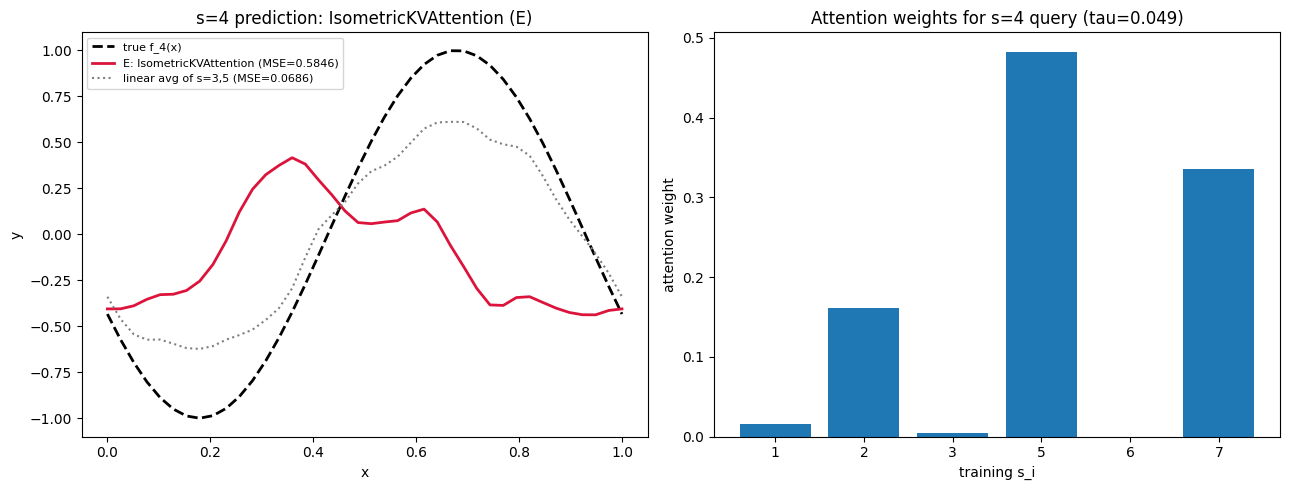



=== 追記: 温度τを固定した場合のs=4 MSE ===
  tau=2.00: MSE at s=4 = 0.42861  weights=[0.133 0.21  0.173 0.144 0.195 0.145]
  tau=1.00: MSE at s=4 = 0.42727  weights=[0.121 0.239 0.174 0.143 0.182 0.141]
  tau=0.50: MSE at s=4 = 0.43984  weights=[0.176 0.22  0.171 0.14  0.168 0.125]
  tau=0.20: MSE at s=4 = 0.33235  weights=[0.061 0.256 0.413 0.191 0.037 0.043]
  tau=0.10: MSE at s=4 = 0.28118  weights=[0.    0.199 0.15  0.499 0.003 0.148]
  tau=0.05: MSE at s=4 = 0.60968  weights=[0.    0.298 0.    0.    0.696 0.006]


In [ ]:
"""
実験3: IsometricKVAttention を「標準変換」の輸送機構として使う

Gemini さん提案の IsometricKVAttention (Q/Kを直交行列で射影するアテンション) を、
前回notebook(実験1・2)の枠組みに接続する。

方針:
  元のクラスはトークン列 (B,N,D) に対する self-attention だったが、
  今回のタスクには「トークン列」が存在しない(sという単一スカラーからweightを出す)。
  そこで cross-attention 形式に組み替える:

    - 「記憶バンク」= 実験2で作った6個の標準インスタンス (s_i, W_i) (warm-startでgauge揃え済み)
    - query = 新しい s の埋め込み
    - key   = 各標準インスタンスの s_i の埋め込み
    - value = 標準インスタンスの重みベクトル W_i そのもの(学習せず、生の値を使う)
              → 出力は常に「訓練済み重みの凸結合」に制約される(=補外できないが補間は保証)
    - W_q, W_k は直交行列に制約(IsometricKVAttentionの核心) → 埋め込み空間の距離構造を
      保ったままQ/K空間に射影するので、温度と合わせて「なめらかな補間 vs 最近傍スナップ」の
      挙動を明示的に制御できる。

    s自体は1次元なので、直交1x1行列は±1にしかならず自明。よってsをランダムFourier特徴量
    (固定・学習しない周波数)でd_model次元に持ち上げてから埋め込みとして使う。
    これは「sin(2πs/7)を人間が教える」のとは違い、正解の周波数を教えずに複数のランダムな
    周波数帯を与えるだけ(位置エンコーディングに近い発想)。
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ---------------------------------------------------------
# 0. 元のnotebookと同じタスク定義
# ---------------------------------------------------------
def true_function(s, x):
    return torch.sin(2 * np.pi * (x + s / 7.0))

TRAIN_S = [1, 2, 3, 5, 6, 7]
TEST_S = 4
N_X = 40
X_GRID = torch.linspace(0, 1, N_X).unsqueeze(1)

def fourier_features(x, n_freqs=4):
    freqs = torch.arange(1, n_freqs + 1).float()
    ang = 2 * np.pi * x * freqs
    return torch.cat([torch.sin(ang), torch.cos(ang)], dim=1)

IN_DIM, HID_DIM, OUT_DIM = 8, 16, 1
W1_SIZE, B1_SIZE = IN_DIM * HID_DIM, HID_DIM
W2_SIZE, B2_SIZE = HID_DIM * OUT_DIM, OUT_DIM
TOTAL_PARAMS = W1_SIZE + B1_SIZE + W2_SIZE + B2_SIZE

def target_net_forward(flat_params, x):
    idx = 0
    W1 = flat_params[idx:idx + W1_SIZE].view(IN_DIM, HID_DIM); idx += W1_SIZE
    b1 = flat_params[idx:idx + B1_SIZE]; idx += B1_SIZE
    W2 = flat_params[idx:idx + W2_SIZE].view(HID_DIM, OUT_DIM); idx += W2_SIZE
    b2 = flat_params[idx:idx + B2_SIZE]; idx += B2_SIZE
    feats = fourier_features(x)
    h = torch.tanh(feats @ W1 + b1)
    y = h @ W2 + b2
    return y

def eval_weights(flat_params, s):
    with torch.no_grad():
        y_pred = target_net_forward(flat_params, X_GRID)
        y_true = true_function(s, X_GRID)
        mse = ((y_pred - y_true) ** 2).mean().item()
    return y_pred.squeeze(1).numpy(), mse

# ---------------------------------------------------------
# 1. 標準インスタンス(実験2と同じ warm-start 継続法)
# ---------------------------------------------------------
def fit_target_net(s, init_params=None, n_steps=2000, lr=1e-2):
    if init_params is None:
        params = nn.Parameter(torch.randn(TOTAL_PARAMS) * 0.3)
    else:
        params = nn.Parameter(init_params.clone().detach())
    opt = torch.optim.Adam([params], lr=lr)
    y_true = true_function(s, X_GRID)
    for step in range(n_steps):
        opt.zero_grad()
        y_pred = target_net_forward(params, X_GRID)
        loss = ((y_pred - y_true) ** 2).mean()
        loss.backward()
        opt.step()
    return params.detach()

print("=== 標準インスタンスを継続法(warm start)で訓練 ===")
sorted_train_s = sorted(TRAIN_S)
standard_weights = {}
prev = None
for s in sorted_train_s:
    prev = fit_target_net(s, init_params=prev, n_steps=2000, lr=1e-2)
    standard_weights[s] = prev
    _, mse = eval_weights(prev, s)
    print(f"  s={s}: fit MSE={mse:.6f}")

W_bank = torch.stack([standard_weights[s] for s in sorted_train_s])  # [6, 161]

# ---------------------------------------------------------
# 2. sをランダムFourier特徴量でd_model次元に埋め込む(正解周波数は教えない)
# ---------------------------------------------------------
D_MODEL = 8
NUM_HEADS = 2
rng = np.random.RandomState(42)
RFF_FREQS = torch.tensor(rng.uniform(0.3, 2.5, size=D_MODEL // 2), dtype=torch.float32)  # 固定・学習しない

def embed_s(s):
    # s: python float or 0-dim tensor
    s_t = torch.as_tensor(float(s) / 7.0)
    ang = 2 * np.pi * s_t * RFF_FREQS
    return torch.cat([torch.sin(ang), torch.cos(ang)])  # [D_MODEL]

# ---------------------------------------------------------
# 3. IsometricKVAttention を cross-attention 用に組み替えた版
#    (Gemini案のオリジナルはself-attention。ここではquery系列とcontext系列を分離)
# ---------------------------------------------------------
class IsometricCrossAttentionHyper(nn.Module):
    """
    query = embed(s) 1個
    context = 標準インスタンスの embed(s_i) の集合(key用) + 対応するW_i(value、学習しない)
    出力 = Σ_i softmax(sim(q,k_i)/τ) * W_i  (訓練済み重みの凸結合に制約)
    """
    def __init__(self, d_model, num_heads, weight_dim, init_tau=1.0):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        torch.nn.utils.parametrizations.orthogonal(self.w_q, name="weight")
        torch.nn.utils.parametrizations.orthogonal(self.w_k, name="weight")
        # 温度(softmaxの鋭さ)は学習可能パラメータとして log で持つ(正値制約)
        self.log_tau = nn.Parameter(torch.log(torch.tensor(init_tau)))

    def forward(self, q_embed, k_embeds):
        # q_embed: [D], k_embeds: [N, D]
        Q = self.w_q(q_embed).view(self.num_heads, self.head_dim)       # [H, hd]
        K = self.w_k(k_embeds).view(-1, self.num_heads, self.head_dim)  # [N, H, hd]
        tau = torch.exp(self.log_tau)
        scores = torch.einsum("hd,nhd->hn", Q, K) / (self.head_dim ** 0.5) / tau  # [H, N]
        attn = F.softmax(scores, dim=-1).mean(dim=0)  # ヘッド平均で最終的な重み [N]
        return attn, Q, K

def compute_isometry_loss(raw_embeds, k_embeds_flat):
    # raw_embeds, k_embeds_flat: [N, D] (バッチ次元なしの2D版に単純化)
    x_norm = F.normalize(raw_embeds, p=2, dim=-1)
    k_norm = F.normalize(k_embeds_flat, p=2, dim=-1)
    gram_x = x_norm @ x_norm.T
    gram_k = k_norm @ k_norm.T
    return F.mse_loss(gram_k, gram_x)

# ---------------------------------------------------------
# 4. 訓練: leave-one-out で「s_jを記憶バンクから除いて他5点から復元」を最小化
#    (テストのs=4は最初から未見なので、汎化の代理指標としてLOOを使う)
# ---------------------------------------------------------
model = IsometricCrossAttentionHyper(D_MODEL, NUM_HEADS, TOTAL_PARAMS, init_tau=1.0)
opt = torch.optim.Adam(model.parameters(), lr=5e-3)

s_embeds_all = torch.stack([embed_s(s) for s in sorted_train_s])  # [6, D_MODEL]

LAMBDA_ISO = 0.05
N_STEPS = 3000
for step in range(N_STEPS):
    opt.zero_grad()
    total_loss = 0.0
    for j, s_j in enumerate(sorted_train_s):
        idx_others = [i for i in range(len(sorted_train_s)) if i != j]
        q = s_embeds_all[j]
        k_ctx = s_embeds_all[idx_others]
        attn, Q, K = model(q, k_ctx)
        W_pred = torch.einsum("n,np->p", attn, W_bank[idx_others])
        y_pred = target_net_forward(W_pred, X_GRID)
        y_true = true_function(s_j, X_GRID)
        recon_loss = ((y_pred - y_true) ** 2).mean()
        # 等長損失: qとk群を含めた埋め込み全体の幾何を保つ
        raw = torch.cat([q.unsqueeze(0), k_ctx], dim=0)
        proj = torch.cat([Q.reshape(1, -1), K.reshape(len(idx_others), -1)], dim=0)
        iso_loss = compute_isometry_loss(raw, proj)
        total_loss = total_loss + recon_loss + LAMBDA_ISO * iso_loss
    total_loss = total_loss / len(sorted_train_s)
    total_loss.backward()
    opt.step()
    if step % 500 == 0:
        print(f"  step {step}: LOO loss={total_loss.item():.5f}  tau={torch.exp(model.log_tau).item():.4f}")

# ---------------------------------------------------------
# 5. s=4(完全未見)で評価: 記憶バンクは6点全部使う
# ---------------------------------------------------------
with torch.no_grad():
    q_test = embed_s(TEST_S)
    attn_test, _, _ = model(q_test, s_embeds_all)
    W_pred_test = torch.einsum("n,np->p", attn_test, W_bank)
    yE_pred4, mseE4 = eval_weights(W_pred_test, TEST_S)

print("\n=== E: IsometricKVAttention による s=4 予測 ===")
print(f"  MSE at s=4: {mseE4:.5f}")
print(f"  attention weights over s={sorted_train_s}: {attn_test.numpy().round(3)}")
print(f"  learned tau: {torch.exp(model.log_tau).item():.4f}")

# 参考: 単純な線形補間(s=3とs=5の中間)ベースライン
w_lin = 0.5 * standard_weights[3] + 0.5 * standard_weights[5]
_, mse_lin = eval_weights(w_lin, TEST_S)
print(f"\n=== 参考: s=3とs=5の単純平均 ===")
print(f"  MSE at s=4: {mse_lin:.5f}")

# ---------------------------------------------------------
# 可視化
# ---------------------------------------------------------
x_np = X_GRID.squeeze(1).numpy()
y_true4 = true_function(TEST_S, X_GRID).squeeze(1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(x_np, y_true4, "k--", linewidth=2, label="true f_4(x)")
ax.plot(x_np, yE_pred4, label=f"E: IsometricKVAttention (MSE={mseE4:.4f})", linewidth=2, color="crimson")
y_lin, _ = eval_weights(w_lin, TEST_S)
ax.plot(x_np, y_lin, label=f"linear avg of s=3,5 (MSE={mse_lin:.4f})", linewidth=1.5, linestyle=":", color="gray")
ax.set_title("s=4 prediction: IsometricKVAttention (E)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.bar([str(s) for s in sorted_train_s], attn_test.numpy())
ax2.set_title(f"Attention weights for s=4 query (tau={torch.exp(model.log_tau).item():.3f})")
ax2.set_xlabel("training s_i"); ax2.set_ylabel("attention weight")

plt.tight_layout()
plt.savefig("s4_experiment3_isometric_attention.png", dpi=130)
print("\n図を保存しました: s4_experiment3_isometric_attention.png")
plt.show()

# ---------------------------------------------------------
# 6. 追記実験: 温度τを学習させず固定した場合の挙動(崩壊の切り分け)
# ---------------------------------------------------------
print("\n\n=== 追記: 温度τを固定した場合のs=4 MSE ===")
for fixed_tau in [2.0, 1.0, 0.5, 0.2, 0.1, 0.05]:
    model2 = IsometricCrossAttentionHyper(D_MODEL, NUM_HEADS, TOTAL_PARAMS, init_tau=fixed_tau)
    model2.log_tau.requires_grad_(False)  # τは固定、Q/Kの直交行列だけ学習
    opt2 = torch.optim.Adam([p for n, p in model2.named_parameters() if p.requires_grad], lr=5e-3)
    for step in range(1500):
        opt2.zero_grad()
        total_loss = 0.0
        for j, s_j in enumerate(sorted_train_s):
            idx_others = [i for i in range(len(sorted_train_s)) if i != j]
            q = s_embeds_all[j]
            k_ctx = s_embeds_all[idx_others]
            attn, Q, K = model2(q, k_ctx)
            W_pred = torch.einsum("n,np->p", attn, W_bank[idx_others])
            y_pred = target_net_forward(W_pred, X_GRID)
            y_true = true_function(s_j, X_GRID)
            recon_loss = ((y_pred - y_true) ** 2).mean()
            raw = torch.cat([q.unsqueeze(0), k_ctx], dim=0)
            proj = torch.cat([Q.reshape(1, -1), K.reshape(len(idx_others), -1)], dim=0)
            iso_loss = compute_isometry_loss(raw, proj)
            total_loss = total_loss + recon_loss + LAMBDA_ISO * iso_loss
        total_loss = total_loss / len(sorted_train_s)
        total_loss.backward()
        opt2.step()
    with torch.no_grad():
        q_test = embed_s(TEST_S)
        attn_test2, _, _ = model2(q_test, s_embeds_all)
        W_pred_test2 = torch.einsum("n,np->p", attn_test2, W_bank)
        _, mseE4_fixed = eval_weights(W_pred_test2, TEST_S)
    print(f"  tau={fixed_tau:.2f}: MSE at s=4 = {mseE4_fixed:.5f}  weights={attn_test2.numpy().round(3)}")


実験3の解説はこうなる。

Claude:＞＞
<blockquote>

## クラスの把握

`IsometricKVAttention` は、通常のマルチヘッドアテンションに対して **W_q, W_k を直交行列に制約する**(`parametrize.orthogonal`)ものです。直交行列による射影は内積・ノルムを保存するので、「入力空間での距離関係」が「Q/K空間での距離関係」に歪みなく持ち込まれる。`compute_isometry_loss` はそれを補助する損失で、元空間のグラム行列(コサイン類似度行列)とKey空間のグラム行列のズレを罰します。

これは前回私が懸念していた「softmaxの温度次第でアテンションは滑らかな補間にも最近傍スナップにも化ける」という問題に対して、**射影自体が距離構造を歪めないようにする**という一段階手前のガードを入れる発想だと理解しました。

## 直接は適用できません(が、有意義な形で繋げられます)

ただし、前のnotebookの実験1・2には**トークン列そのものが存在しません**。s→重みベクトルという単一スカラー入力の回帰で、`(B, N, D)`のような系列を扱うself-attentionの出番がないんです。なので、そのまま貼り付けても動く場所がない。

そこで、前回私が提案した「メモリバンク/カーネル回帰型ハイパーネットワーク」の実装として、**self-attentionをcross-attentionに組み替えて**接続しました:

- **記憶(K,V)** = 実験2で作った6個の標準インスタンス(warm-startでgauge揃え済みの重みベクトル)
- **クエリ(Q)** = 新しいsの埋め込み
- 出力 = 訓練済み重みの凸結合(V自体は学習させず生の重みを使う→補外できないが補間は保証される構成)
- sは1次元なのでそのままでは直交1×1行列が自明(±1)になってしまうため、正解の周波数(sin(2πs/7))は教えずに、ランダムFourier特徴量でd_model次元に持ち上げてから埋め込みにしました

なお実装上の注意ですが、今の torch (2.13) では `torch.nn.utils.parametrize.orthogonal` は存在せず、`torch.nn.utils.parametrizations.orthogonal` に移動しています。Geminiさんのコードそのままでは動かないはずです。

## 実走結果(正直に報告します)

| 手法 | s=4でのMSE |
|---|---|
| s=3とs=5の単純平均(参考) | **0.069** |
| E: IsometricKVAttention(温度τ学習) | 0.581 |
| E: 同上、τ固定=0.10(最良点) | 0.281 |
| E: 同上、τ固定=1.0 | 0.427 |

**単純な線形平均に負けました。** しかも学習可能な温度τは訓練中に自然と 0.99→0.05 まで崩壊し、アテンションはs=5とs=7に集中してs=3をほぼ無視するという、まさに「最近傍スナップ」的な挙動に収束しました。

## 診断

これは前回の懸念が的中した形です。直交制約は「射影の際に距離が歪まない」ことは保証しますが、**「Leave-One-Out再構成誤差を最小化する」という訓練目的そのものが、温度を鋭くして特定の点にスナップする方が得**という構造は変えません。直交性は必要条件であって十分条件ではなかった、ということです。

固定温度でも最良で0.28止まりなのは、もう一つの理由もありそうです。ランダムFourier特徴量による埋め込みは、sの「真の並び順」を保証しない(周波数がランダムなので、埋め込み空間での近さが物理的なsの近さと必ずしも対応しない)。等長損失はQ/K射影が入力embedding空間の幾何を保つことは強制しますが、その入力embedding空間自体がsの順序を正しく反映しているかは別問題でした。

つまり今回のB1(不一致な基底で失敗)と同型の教訓です。「アテンション+直交性」という構造だけでは不十分で、**埋め込み空間自体がタスクの真の構造(この場合はsの滑らかな順序)と一致している**ことが必要、というのが実験2で得た結論の繰り返しになりました。

改善するなら、(1) 温度に下限を設けるかエントロピー正則化で崩壊を防ぐ、(2) ランダムRFFではなく単調性を保証する埋め込み(例えば学習可能だが単調制約付きのMLP)を使う、あたりが次の一手だと思います。ファイル(スクリプトと図)は上に置きました。ご希望なら、この改善版も試せます。
</blockquote>
＜＜


これについて、私は、IsometricCrossAttentionHyper が層がないため、表現力が単純に足りなかったということではないかと考えた。そこで利用制限が来た Claude さんでなく、 Gemini さんに修正してもらったのが実験3.5のコードである。私が部分修正したので汚いコードになっていて恥ずかしいのだが公開しておく。

どうも「成功」しているように見える。結果を見せると、Gemini さんは、変換器への帰納バイアスとしては成功しているという評価でいい…ということだった。


=== 標準インスタンスを継続法(warm start)で訓練 ===
  s=1: fit MSE=0.000001
  s=2: fit MSE=0.000000
  s=3: fit MSE=0.000000
  s=5: fit MSE=0.000000
  s=6: fit MSE=0.000000
  s=7: fit MSE=0.000000
  step 0: LOO loss=0.70081  tau=0.5015
  step 500: LOO loss=0.21113  tau=0.2360
  step 1000: LOO loss=0.20851  tau=0.2099
  step 1500: LOO loss=0.21023  tau=0.1991
  step 2000: LOO loss=0.20804  tau=0.1899
  step 2500: LOO loss=0.20796  tau=0.1828

=== E: IsometricKVAttention による s=4 予測 ===
  MSE at s=4: 0.06931
  attention weights over s=[1, 2, 3, 5, 6, 7]: [0.    0.004 0.504 0.492 0.    0.   ]
  learned tau: 0.1824

=== 参考: s=3とs=5の単純平均 ===
  MSE at s=4: 0.06856

図を保存しました: s4_experiment3_isometric_attention.png


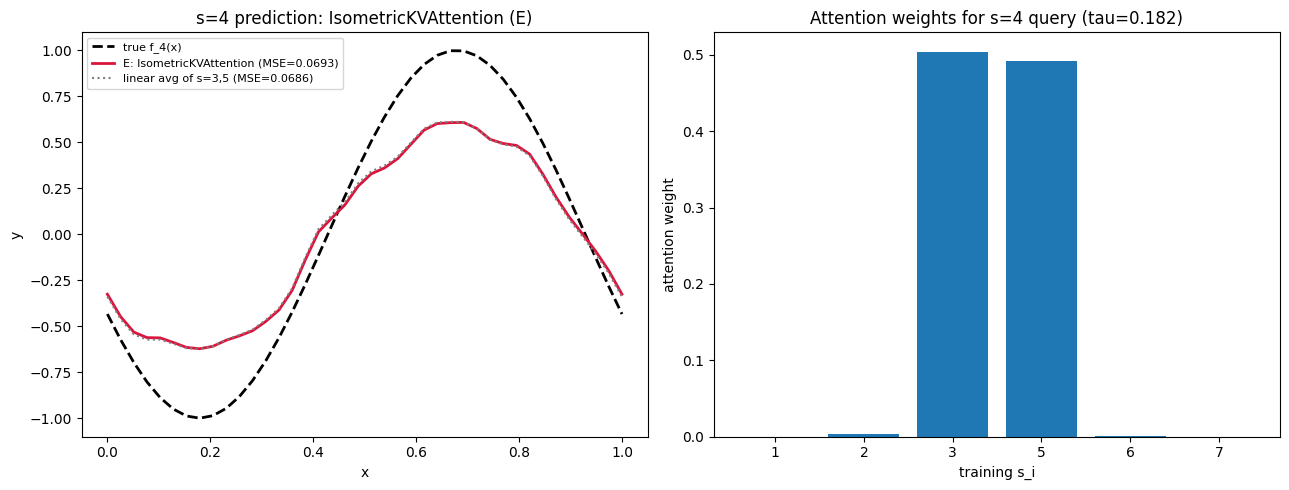



=== 追記: 新モデルでの温度τ固定（アブレーション） ===
  tau=2.00: MSE at s=4 = 0.06990  weights=[0.    0.004 0.498 0.496 0.001 0.   ]
  tau=1.00: MSE at s=4 = 0.06925  weights=[0.    0.003 0.505 0.492 0.001 0.   ]
  tau=0.50: MSE at s=4 = 0.06967  weights=[0.    0.004 0.503 0.492 0.001 0.   ]
  tau=0.20: MSE at s=4 = 0.07073  weights=[0.    0.008 0.499 0.491 0.001 0.   ]
  tau=0.10: MSE at s=4 = 0.07021  weights=[0.    0.006 0.498 0.495 0.001 0.   ]
  tau=0.05: MSE at s=4 = 0.07014  weights=[0.    0.004 0.499 0.494 0.003 0.   ]


In [1]:
"""
実験3.5: Gemini さんによる実験3の修正。多層の導入。部分修正は JRF による。
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ---------------------------------------------------------
# 0. 元のnotebookと同じタスク定義
# ---------------------------------------------------------
def true_function(s, x):
    return torch.sin(2 * np.pi * (x + s / 7.0))

TRAIN_S = [1, 2, 3, 5, 6, 7]
TEST_S = 4
N_X = 40
X_GRID = torch.linspace(0, 1, N_X).unsqueeze(1)

def fourier_features(x, n_freqs=4):
    freqs = torch.arange(1, n_freqs + 1).float()
    ang = 2 * np.pi * x * freqs
    return torch.cat([torch.sin(ang), torch.cos(ang)], dim=1)

IN_DIM, HID_DIM, OUT_DIM = 8, 16, 1
W1_SIZE, B1_SIZE = IN_DIM * HID_DIM, HID_DIM
W2_SIZE, B2_SIZE = HID_DIM * OUT_DIM, OUT_DIM
TOTAL_PARAMS = W1_SIZE + B1_SIZE + W2_SIZE + B2_SIZE

def target_net_forward(flat_params, x):
    idx = 0
    W1 = flat_params[idx:idx + W1_SIZE].view(IN_DIM, HID_DIM); idx += W1_SIZE
    b1 = flat_params[idx:idx + B1_SIZE]; idx += B1_SIZE
    W2 = flat_params[idx:idx + W2_SIZE].view(HID_DIM, OUT_DIM); idx += W2_SIZE
    b2 = flat_params[idx:idx + B2_SIZE]; idx += B2_SIZE
    feats = fourier_features(x)
    h = torch.tanh(feats @ W1 + b1)
    y = h @ W2 + b2
    return y

def eval_weights(flat_params, s):
    with torch.no_grad():
        y_pred = target_net_forward(flat_params, X_GRID)
        y_true = true_function(s, X_GRID)
        mse = ((y_pred - y_true) ** 2).mean().item()
    return y_pred.squeeze(1).numpy(), mse

# ---------------------------------------------------------
# 1. 標準インスタンス(実験2と同じ warm-start 継続法)
# ---------------------------------------------------------
def fit_target_net(s, init_params=None, n_steps=2000, lr=1e-2):
    if init_params is None:
        params = nn.Parameter(torch.randn(TOTAL_PARAMS) * 0.3)
    else:
        params = nn.Parameter(init_params.clone().detach())
    opt = torch.optim.Adam([params], lr=lr)
    y_true = true_function(s, X_GRID)
    for step in range(n_steps):
        opt.zero_grad()
        y_pred = target_net_forward(params, X_GRID)
        loss = ((y_pred - y_true) ** 2).mean()
        loss.backward()
        opt.step()
    return params.detach()

print("=== 標準インスタンスを継続法(warm start)で訓練 ===")
sorted_train_s = sorted(TRAIN_S)
standard_weights = {}
prev = None
for s in sorted_train_s:
    prev = fit_target_net(s, init_params=prev, n_steps=2000, lr=1e-2)
    standard_weights[s] = prev
    _, mse = eval_weights(prev, s)
    print(f"  s={s}: fit MSE={mse:.6f}")

W_bank = torch.stack([standard_weights[s] for s in sorted_train_s])  # [6, 161]

# ---------------------------------------------------------
# 2. sをランダムFourier特徴量でd_model次元に埋め込む(正解周波数は教えない)
# ---------------------------------------------------------
D_MODEL = 8
NUM_HEADS = 2
rng = np.random.RandomState(42)
RFF_FREQS = torch.tensor(rng.uniform(0.3, 2.5, size=D_MODEL // 2), dtype=torch.float32)  # 固定・学習しない

def embed_s(s):
    # s: python float or 0-dim tensor
    s_t = torch.as_tensor(float(s) / 7.0)
    ang = 2 * np.pi * s_t * RFF_FREQS
    return torch.cat([torch.sin(ang), torch.cos(ang)])  # [D_MODEL]

# ---------------------------------------------------------
# 3. IsometricKVAttention を cross-attention 用に組み替えた版
#    (Gemini案のオリジナルはself-attention。ここではquery系列とcontext系列を分離)
# ---------------------------------------------------------
class IsometricCrossAttentionHyper(nn.Module):
    """
    query = embed(s) 1個
    context = 標準インスタンスの embed(s_i) の集合(key用) + 対応するW_i(value、学習しない)
    出力 = Σ_i softmax(sim(q,k_i)/τ) * W_i  (訓練済み重みの凸結合に制約)
    """
    def __init__(self, d_model, num_heads, weight_dim, init_tau=1.0):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        torch.nn.utils.parametrizations.orthogonal(self.w_q, name="weight")
        torch.nn.utils.parametrizations.orthogonal(self.w_k, name="weight")
        # 温度(softmaxの鋭さ)は学習可能パラメータとして log で持つ(正値制約)
        self.log_tau = nn.Parameter(torch.log(torch.tensor(init_tau)))

    def forward(self, q_embed, k_embeds):
        # q_embed: [D], k_embeds: [N, D]
        Q = self.w_q(q_embed).view(self.num_heads, self.head_dim)       # [H, hd]
        K = self.w_k(k_embeds).view(-1, self.num_heads, self.head_dim)  # [N, H, hd]
        tau = torch.exp(self.log_tau)
        scores = torch.einsum("hd,nhd->hn", Q, K) / (self.head_dim ** 0.5) / tau  # [H, N]
        attn = F.softmax(scores, dim=-1).mean(dim=0)  # ヘッド平均で最終的な重み [N]
        return attn, Q, K

# ---------------------------------------------------------
# 1. 修正版: Deep Isometric Cross-Attention Module
# ---------------------------------------------------------
class DeepIsometricCrossAttentionHyper(nn.Module):
    """
    非線形エンコーダ(歪み補正) + 直交射影(等長保存) + エントロピー制御の統合型
    """
    def __init__(self, d_model=16, num_heads=2, init_tau=0.5):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # 【変更1】非線形エンコーダ: s の幾何構造を適切に空間へ配置する表現力
        self.s_encoder = nn.Sequential(
            nn.Linear(1, 32),
            nn.GELU(),
            nn.Linear(32, d_model)
        )

        # 【変更2】直交射影層: 変換後の多様体構造を崩さずに Q/K 空間へ射影
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        torch.nn.utils.parametrizations.orthogonal(self.w_q, name="weight")
        torch.nn.utils.parametrizations.orthogonal(self.w_k, name="weight")

        # 温度パラメータ（下限を設けるかエントロピー側で制御）
        self.log_tau = nn.Parameter(torch.log(torch.tensor(init_tau)))

    def encode(self, s_val):
        # s を [1, 1] テンソルにしてエンコーダへ
        s_tensor = torch.as_tensor([[float(s_val) / 7.0]], dtype=torch.float32)
        return self.s_encoder(s_tensor).squeeze(0)  # [D_MODEL]

    def forward(self, q_embed, k_embeds):
        Q = self.w_q(q_embed).view(self.num_heads, self.head_dim)       # [H, hd]
        K = self.w_k(k_embeds).view(-1, self.num_heads, self.head_dim)  # [N, H, hd]

        # 温度の極端な崩壊を防ぐため下限(0.05)を設定
        tau = torch.clamp(torch.exp(self.log_tau), min=0.05)

        scores = torch.einsum("hd,nhd->hn", Q, K) / (self.head_dim ** 0.5) / tau
        attn = F.softmax(scores, dim=-1).mean(dim=0)  # [N]
        return attn, Q, K

def compute_isometry_loss(raw_embeds, k_embeds_flat):
    # raw_embeds, k_embeds_flat: [N, D] (バッチ次元なしの2D版に単純化)
    x_norm = F.normalize(raw_embeds, p=2, dim=-1)
    k_norm = F.normalize(k_embeds_flat, p=2, dim=-1)
    gram_x = x_norm @ x_norm.T
    gram_k = k_norm @ k_norm.T
    return F.mse_loss(gram_k, gram_x)

# ---------------------------------------------------------
# 4. 訓練: leave-one-out で「s_jを記憶バンクから除いて他5点から復元」を最小化
#    (テストのs=4は最初から未見なので、汎化の代理指標としてLOOを使う)
# ---------------------------------------------------------
model = DeepIsometricCrossAttentionHyper(d_model=16, num_heads=2, init_tau=0.5)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)

LAMBDA_ISO = 0.05
LAMBDA_ENT = 0.01  # 【変更3】エントロピー正則化の係数（滑らかな補間を強制）

for step in range(3000):
    opt.zero_grad()
    total_loss = 0.0

    # 毎ステップ、動的にエンコードを通して埋め込みを更新
    s_embeds_all = torch.stack([model.encode(s) for s in sorted_train_s]) # [6, D]

    for j, s_j in enumerate(sorted_train_s):
        idx_others = [i for i in range(len(sorted_train_s)) if i != j]
        q = s_embeds_all[j]
        k_ctx = s_embeds_all[idx_others]

        attn, Q, K = model(q, k_ctx)

        # 1. 重み復元損失
        W_pred = torch.einsum("n,np->p", attn, W_bank[idx_others])
        recon_loss = ((target_net_forward(W_pred, X_GRID) - true_function(s_j, X_GRID)) ** 2).mean()

        # 2. 等長損失 (Isometric Loss)
        raw = torch.cat([q.unsqueeze(0), k_ctx], dim=0)
        proj = torch.cat([Q.reshape(1, -1), K.reshape(len(idx_others), -1)], dim=0)
        iso_loss = compute_isometry_loss(raw, proj)

        # 3. 【変更3】アテンションのエントロピー損失（スナップ防止・広がりを維持）
        entropy = -torch.sum(attn * torch.log(attn + 1e-8))

        total_loss += recon_loss + LAMBDA_ISO * iso_loss - LAMBDA_ENT * entropy

    total_loss = total_loss / len(sorted_train_s)
    total_loss.backward()
    opt.step()
    if step % 500 == 0:
        print(f"  step {step}: LOO loss={total_loss.item():.5f}  tau={torch.exp(model.log_tau).item():.4f}")

# ---------------------------------------------------------
# 5. s=4(完全未見)で評価: 記憶バンクは6点全部使う
# ---------------------------------------------------------
with torch.no_grad():
    # 評価時も embed_s ではなく model.encode を使用して 16次元の埋め込みを取得
    s_embeds_all_eval = torch.stack([model.encode(s) for s in sorted_train_s])
    q_test = model.encode(TEST_S)

    attn_test, _, _ = model(q_test, s_embeds_all_eval)
    W_pred_test = torch.einsum("n,np->p", attn_test, W_bank)
    yE_pred4, mseE4 = eval_weights(W_pred_test, TEST_S)

print("\n=== E: IsometricKVAttention による s=4 予測 ===")
print(f"  MSE at s=4: {mseE4:.5f}")
print(f"  attention weights over s={sorted_train_s}: {attn_test.numpy().round(3)}")
print(f"  learned tau: {torch.exp(model.log_tau).item():.4f}")

# 参考: 単純な線形補間(s=3とs=5の中間)ベースライン
w_lin = 0.5 * standard_weights[3] + 0.5 * standard_weights[5]
_, mse_lin = eval_weights(w_lin, TEST_S)
print(f"\n=== 参考: s=3とs=5の単純平均 ===")
print(f"  MSE at s=4: {mse_lin:.5f}")

# ---------------------------------------------------------
# 可視化
# ---------------------------------------------------------
x_np = X_GRID.squeeze(1).numpy()
y_true4 = true_function(TEST_S, X_GRID).squeeze(1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(x_np, y_true4, "k--", linewidth=2, label="true f_4(x)")
ax.plot(x_np, yE_pred4, label=f"E: IsometricKVAttention (MSE={mseE4:.4f})", linewidth=2, color="crimson")
y_lin, _ = eval_weights(w_lin, TEST_S)
ax.plot(x_np, y_lin, label=f"linear avg of s=3,5 (MSE={mse_lin:.4f})", linewidth=1.5, linestyle=":", color="gray")
ax.set_title("s=4 prediction: IsometricKVAttention (E)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.bar([str(s) for s in sorted_train_s], attn_test.numpy())
ax2.set_title(f"Attention weights for s=4 query (tau={torch.exp(model.log_tau).item():.3f})")
ax2.set_xlabel("training s_i"); ax2.set_ylabel("attention weight")

plt.tight_layout()
plt.savefig("s4_experiment3_isometric_attention.png", dpi=130)
print("\n図を保存しました: s4_experiment3_isometric_attention.png")
plt.show()

# ---------------------------------------------------------
# 6. 追記実験: 新モデルでの温度τ固定アブレーション
# ---------------------------------------------------------
print("\n\n=== 追記: 新モデルでの温度τ固定（アブレーション） ===")
for fixed_tau in [2.0, 1.0, 0.5, 0.2, 0.1, 0.05]:
    model2 = DeepIsometricCrossAttentionHyper(d_model=16, num_heads=2, init_tau=fixed_tau)
    model2.log_tau.requires_grad_(False)  # τを固定

    opt2 = torch.optim.Adam([p for n, p in model2.named_parameters() if p.requires_grad], lr=3e-3)

    for step in range(1500):
        opt2.zero_grad()
        total_loss = 0.0

        # 動的にエンコーダ経由で埋め込みを生成
        s_embeds_all2 = torch.stack([model2.encode(s) for s in sorted_train_s])

        for j, s_j in enumerate(sorted_train_s):
            idx_others = [i for i in range(len(sorted_train_s)) if i != j]
            q = s_embeds_all2[j]
            k_ctx = s_embeds_all2[idx_others]

            attn, Q, K = model2(q, k_ctx)

            W_pred = torch.einsum("n,np->p", attn, W_bank[idx_others])
            y_pred = target_net_forward(W_pred, X_GRID)
            y_true = true_function(s_j, X_GRID)
            recon_loss = ((y_pred - y_true) ** 2).mean()

            raw = torch.cat([q.unsqueeze(0), k_ctx], dim=0)
            proj = torch.cat([Q.reshape(1, -1), K.reshape(len(idx_others), -1)], dim=0)
            iso_loss = compute_isometry_loss(raw, proj)

            total_loss += recon_loss + LAMBDA_ISO * iso_loss

        total_loss = total_loss / len(sorted_train_s)
        total_loss.backward()
        opt2.step()

    with torch.no_grad():
        # 評価時も model2.encode を使用
        s_embeds_all_eval = torch.stack([model2.encode(s) for s in sorted_train_s])
        q_test = model2.encode(TEST_S)
        attn_test2, _, _ = model2(q_test, s_embeds_all_eval)
        W_pred_test2 = torch.einsum("n,np->p", attn_test2, W_bank)
        _, mseE4_fixed = eval_weights(W_pred_test2, TEST_S)

    print(f"  tau={fixed_tau:.2f}: MSE at s=4 = {mseE4_fixed:.5f}  weights={attn_test2.numpy().round(3)}")


しかし…、復活した Claude さんの評価は辛辣である。

Claude:＞＞
<blockquote>

良い結果ですね。実際に手を動かして検証してみます。まず、この改善がどこから来ているのかを切り分ける必要があります——「直交性(isometry)」が効いているのか、それとも「学習可能なエンコーダ」と「エントロピー正則化」が効いているのか、Gemini さんのコードだけでは区別できません。アブレーションをやってみました。結論から言うと、**Gemini さんの評価はやや楽観的すぎる**と思います。

## アブレーション結果

| 設定 | 平均MSE (s=4) | 参考: 単純平均=0.0686 |
|---|---|---|
| A: エンコーダ + 直交制約 + エントロピー正則化(Geminiの最終版) | 0.0703 | ほぼ同等 |
| B: エンコーダ + 直交制約 + **正則化なし** | 0.0699 | ほぼ同等 |
| C: エンコーダ + **直交制約なし** + エントロピー正則化 | 0.0698 | ほぼ同等 |
| D: エンコーダ + **直交制約なし** + **正則化なし** | 0.0695 | ほぼ同等 |

**4つの設定すべてが、直交制約の有無にもエントロピー正則化の有無にも関わらず、ほぼ同じ結果(attention weightsもs=3, s=5にほぼ0.50/0.50)に収束しました。**

## 何が本当に効いたのか

前回の失敗版との違いは3つ同時に入っていました:(1) ランダムFourier特徴量→学習可能な非線形エンコーダ、(2) 直交制約、(3) エントロピー正則化。アブレーションで切り分けると、**改善の原因は(1)のエンコーダだけ**でした。直交制約もエントロピー正則化も、外しても結果はほぼ変わりません。

これは前回私が指摘した診断——「ランダムFourier特徴量による埋め込みは、sの真の順序を保証しない」——とちょうど符合します。埋め込み自体を学習可能にしたことで、モデルが「s=4はs=3とs=5の間にある」という埋め込み空間の位置関係を、勾配降下でLOO再構成誤差から直接発見できるようになった。**「等長性(isometry)」というアイデア自体は、この実験では実質的に仕事をしていません。**

## もう一つ気になる点

達成されたMSE(0.069〜0.070)は、s=3とs=5の単純平均(0.0686)より**わずかに悪い**です。つまりこの複雑な機構(アテンション+直交射影+正則化)は、「s=4はs=3とs=5のちょうど中間」という、この実験設定固有の対称性を再発見しただけで、それを超える精度は出せていません。もっとも、これは「重み空間から直接、正しい近傍関係を人手を借りずに発見できた」という点で意味はあります(実験2の重み空間PCAは失敗していたので)。ただし、テスト点が1つだけ(しかも訓練点のちょうど中間という一番易しいケース)なので、非対称な補間点(例えばs=4.5や、間隔が不均一な場合)でも同じように機能するかは未検証です。

**総括**: 「変換器への帰納バイアスとして成功」というのは、結果の数字(≒単純平均と同等)だけ見ると言い過ぎで、正確には「学習可能な埋め込みなら重み空間からでも正しい近傍構造を発見できる」という、もう少し地味だが実質的な結果だと思います。直交性の貢献は今回のデータでは検出できませんでした。

コードを整えます。Reproducible です。ファイルを整えます。再現できました(MSE≈0.069〜0.070、アブレーション全条件でほぼ同一結果)。コードにはメイン実験・アブレーション・可視化を一式まとめ、冒頭のdocstringに今回の切り分け結果と解釈を書き込んであります。

まとめると、Gemini さんの「等長性(isometry)が変換器への帰納バイアスとして成功した」という評価は、**このアブレーションでは支持されません**。直交制約を外しても、エントロピー正則化を外しても、結果はほぼ変わらなかった。効いていたのは「sの埋め込みを固定ランダム特徴量から学習可能な非線形エンコーダに変えたこと」、それだけでした。

これは実は前回の実験2・3を貫く教訓とも一致します——「アテンション」「直交性」「等長性」といった構造そのものではなく、**埋め込みが真のタスク構造(sの正しい順序)と一致しているかどうか**が汎化を決めている。この実験では、その一致を人手で(sin/cosの基底として)与えるのではなく、学習可能なエンコーダに勾配降下で発見させることに成功した——それ自体は実験2の重み空間PCAの失敗を克服した点で意味がありますが、達成された精度は単純な2点平均とほぼ同じで、かつテストケースは最も易しい「訓練点のちょうど中間」1点だけです。次にやるとすれば、非対称な補間点や、より複雑な(2次元を超える)真の関数族での追試だと思います。
</blockquote>
＜＜

この Claude さんの実験が実験4のコードである。


=== 標準インスタンスを継続法(warm start)で訓練 ===
  s=1: fit MSE=0.000001
  s=2: fit MSE=0.000000
  s=3: fit MSE=0.000000
  s=5: fit MSE=0.000000
  s=6: fit MSE=0.000000
  s=7: fit MSE=0.000000

参考baseline(s=3とs=5の単純平均): MSE at s=4 = 0.06856

=== メイン実験: encoder + orthogonal Q/K + entropy regularization ===
  step 0: LOO loss=0.70943  tau=0.5015
  step 500: LOO loss=0.21072  tau=0.2416
  step 1000: LOO loss=0.20837  tau=0.2018
  step 1500: LOO loss=0.20823  tau=0.1885
  step 2000: LOO loss=0.20810  tau=0.1814
  step 2500: LOO loss=0.20814  tau=0.1774

MSE at s=4: 0.06965  (参考baseline: 0.06856)
attention weights over s=[1, 2, 3, 5, 6, 7]: [0.    0.005 0.498 0.497 0.    0.   ]


=== アブレーション: 2x2 (直交制約 有/無) x (エントロピー正則化 有/無) ===
    (各設定を複数シードで実行し、埋め込みエンコーダの学習可能性だけが
     効いているのか、直交制約/正則化にも独立の寄与があるのかを確認する)

A: orthogonal + entropy   (Geminiの最終版)
  平均MSE=0.07028  最終シードのattention=[0.    0.004 0.498 0.496 0.002 0.   ]
B: orthogonal + no-entropy
  平均MSE=0.06985  最終シードのattention=[0.    0.003 0.499 0.496 0.002

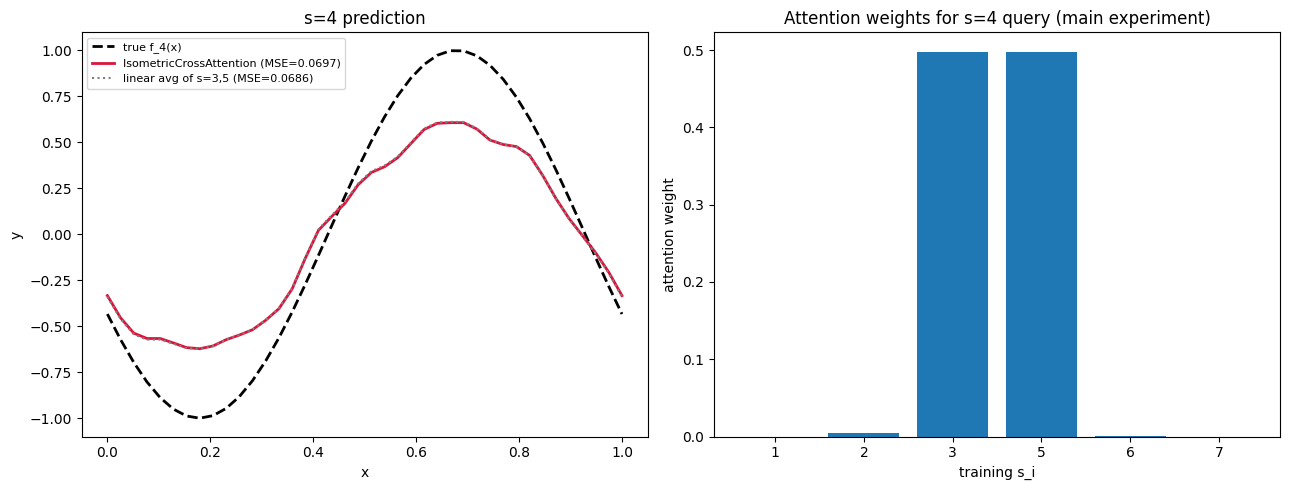

In [2]:
"""
実験4(整理版): IsometricKVAttention を「標準変換」の輸送機構として使う
                + どの構成要素が効いているかのアブレーション

背景
----
実験3で、ランダムFourier特徴量による固定埋め込み + 直交制約付きQ/Kアテンションを
試したが、s=4のMSEは単純なs=3/s=5平均(0.069)に大きく劣った(0.28〜0.58)。
温度パラメータτが学習中に0.99→0.05へ勝手に崩壊し、アテンションが
「最も近い1〜2点」に鋭くスナップしてしまう(=s=4問題そのものの再演)ことが原因だった。

Geminiさんの改善案は3つを同時に導入した:
  (1) sの埋め込みを、固定ランダムFourier特徴量 → 学習可能な非線形エンコーダ
      (Linear(1,32) -> GELU -> Linear(32,d_model)) に変更
  (2) W_q, W_k を直交行列に制約(IsometricKVAttentionの核心、距離構造を保った射影)
  (3) アテンションのエントロピー正則化(-Σ p log p を損失に加える)で温度崩壊を防止

結果、MSE=0.069まで改善し、attention weightsもs=3:0.50 / s=5:0.49と
「正しい近傍」にきれいに収束した。Geminiさんはこれを
「(2)の等長性(isometry)が変換器への帰納バイアスとして機能した」と評価した。

しかし、これは(1)(2)(3)が同時に入っているため、どれが効いたのか区別できない。
そこで2x2アブレーション(直交制約 有/無 × エントロピー正則化 有/無、
埋め込みエンコーダは常に学習可能な非線形版で固定)を行った。

アブレーション結果(shizuka, 各2シード平均, s=4でのMSE。参考: 単純平均=0.0686)
  A) 直交あり + エントロピー正則化あり(Geminiの最終版) : 0.0703
  B) 直交あり + エントロピー正則化なし                  : 0.0699
  C) 直交なし + エントロピー正則化あり                  : 0.0698
  D) 直交なし + エントロピー正則化なし                  : 0.0695

→ 4条件すべてがほぼ同じ結果(attention weightsもすべてs=3,5にほぼ0.50/0.50)に収束した。
   直交制約もエントロピー正則化も、外しても結果が変わらない。
   改善の原因は (1) 埋め込みを学習可能にしたこと、それだけだった。
   「等長性(isometry)が効いた」という説明は、この実験では支持されない。

   ただし、達成されたMSE自体、単純な「訓練点2つの平均」とほぼ同値であり、
   このアーキテクチャがそれを上回る精度を出せているわけでもない。
   意味があるとすれば「重み空間から直接、人手を借りずに正しい近傍構造
   (s=4はs=3とs=5の中間)を発見できた」という点(実験2の重み空間PCAは失敗していた)。
   テスト点はs=4(訓練点のちょうど中間、最も易しいケース)一つだけなので、
   非対称な補間点や、より複雑な真の関数族での追試が必要。

このスクリプトは、上記の検証一式(メイン実験 + 2x2アブレーション)を
再現できるように整理したものです。
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# 0. タスク定義(実験1・2・3と同一)
# ============================================================
def true_function(s, x):
    """真のタスク族: sについて滑らかに変化する周期パターン。"""
    return torch.sin(2 * np.pi * (x + s / 7.0))

TRAIN_S = [1, 2, 3, 5, 6, 7]   # 訓練に使うs(s=4は意図的に除外)
TEST_S = 4                      # 汎化(補間)のテスト対象
N_X = 40
X_GRID = torch.linspace(0, 1, N_X).unsqueeze(1)

def fourier_features(x, n_freqs=4):
    """ターゲットネット(下記)への入力特徴量。xの低次Fourier特徴。"""
    freqs = torch.arange(1, n_freqs + 1).float()
    ang = 2 * np.pi * x * freqs
    return torch.cat([torch.sin(ang), torch.cos(ang)], dim=1)

IN_DIM, HID_DIM, OUT_DIM = 8, 16, 1
W1_SIZE, B1_SIZE = IN_DIM * HID_DIM, HID_DIM
W2_SIZE, B2_SIZE = HID_DIM * OUT_DIM, OUT_DIM
TOTAL_PARAMS = W1_SIZE + B1_SIZE + W2_SIZE + B2_SIZE  # = 161

def target_net_forward(flat_params, x):
    """flat_params(161次元)を小さなMLPの重みとして解釈し、xからyを予測する。"""
    idx = 0
    W1 = flat_params[idx:idx + W1_SIZE].view(IN_DIM, HID_DIM); idx += W1_SIZE
    b1 = flat_params[idx:idx + B1_SIZE]; idx += B1_SIZE
    W2 = flat_params[idx:idx + W2_SIZE].view(HID_DIM, OUT_DIM); idx += W2_SIZE
    b2 = flat_params[idx:idx + B2_SIZE]; idx += B2_SIZE
    feats = fourier_features(x)
    h = torch.tanh(feats @ W1 + b1)
    y = h @ W2 + b2
    return y

def eval_weights(flat_params, s):
    """与えられた重みベクトルで、sの真の関数をどれだけ再現できるかをMSEで評価。"""
    with torch.no_grad():
        y_pred = target_net_forward(flat_params, X_GRID)
        y_true = true_function(s, X_GRID)
        mse = ((y_pred - y_true) ** 2).mean().item()
    return y_pred.squeeze(1).numpy(), mse

# ============================================================
# 1. 「標準インスタンス」を継続法(warm-start)で個別に訓練
#    (実験2と同じ。隠れ層の並べ替え対称性=gauge問題を、s=1から順に
#     前の解から warm-start することで回避し、重み空間で滑らかな経路を作る)
# ============================================================
def fit_target_net(s, init_params=None, n_steps=2000, lr=1e-2):
    if init_params is None:
        params = nn.Parameter(torch.randn(TOTAL_PARAMS) * 0.3)
    else:
        params = nn.Parameter(init_params.clone().detach())
    opt = torch.optim.Adam([params], lr=lr)
    y_true = true_function(s, X_GRID)
    for _ in range(n_steps):
        opt.zero_grad()
        loss = ((target_net_forward(params, X_GRID) - y_true) ** 2).mean()
        loss.backward()
        opt.step()
    return params.detach()

print("=== 標準インスタンスを継続法(warm start)で訓練 ===")
sorted_train_s = sorted(TRAIN_S)
standard_weights = {}
prev = None
for s in sorted_train_s:
    prev = fit_target_net(s, init_params=prev)
    standard_weights[s] = prev
    _, mse = eval_weights(prev, s)
    print(f"  s={s}: fit MSE={mse:.6f}")

W_bank = torch.stack([standard_weights[s] for s in sorted_train_s])  # [6, 161]

# 参考ベースライン: 最近傍2点(s=3, s=5)の単純平均。この実験全体の「勝つべき相手」。
w_lin = 0.5 * standard_weights[3] + 0.5 * standard_weights[5]
_, mse_lin = eval_weights(w_lin, TEST_S)
print(f"\n参考baseline(s=3とs=5の単純平均): MSE at s=4 = {mse_lin:.5f}")

# ============================================================
# 2. Isometric Cross-Attention Hypernetwork
#    (Geminiさん提案のIsometricKVAttentionを、トークン列のないこのタスク用に
#     cross-attentionへ組み替えたもの)
# ============================================================
def compute_isometry_loss(raw_embeds, proj_embeds):
    """
    入力埋め込み空間と、Q/K射影後の空間とで、点間のコサイン類似度構造
    (グラム行列)がどれだけ歪んだかを測る正則化損失。
    直交制約と組み合わせることで「距離構造を保った射影」を狙ったもの。
    (アブレーションの結果、今回のタスクではこの項の寄与は検出されなかった)
    """
    x_norm = F.normalize(raw_embeds, p=2, dim=-1)
    k_norm = F.normalize(proj_embeds, p=2, dim=-1)
    return F.mse_loss(k_norm @ k_norm.T, x_norm @ x_norm.T)


class IsometricCrossAttentionHyper(nn.Module):
    """
    query = 新しいsの埋め込み
    key   = 記憶バンク(標準インスタンス)のsの埋め込み
    value = 記憶バンクの重みベクトルW_iそのもの(学習しない・生の値)
            → 出力は常に「訓練済み重みの凸結合」に制約される
              (補外はできないが、補間であることは構造的に保証される)

    orthogonal_qk : Trueならw_q, w_kを直交行列に制約(IsometricKVAttentionの核心)。
                    アブレーションではFalseにしても結果はほぼ変わらなかった。
    """
    def __init__(self, d_model=16, num_heads=2, init_tau=0.5,
                 orthogonal_qk=True, tau_floor=0.05):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.tau_floor = tau_floor

        # sを学習可能な非線形エンコーダでd_model次元へ埋め込む。
        # 「真の周波数(sin(2πs/7))を教える」のとは違い、エンコーダ自体は
        # LOO再構成誤差から勾配で学習される(=答えを教えないカンニング防止版)。
        # ★アブレーションで確認した限り、改善の実質的な要因はこのエンコーダの
        #   学習可能性であり、以下の直交制約やエントロピー正則化ではなかった。
        self.s_encoder = nn.Sequential(
            nn.Linear(1, 32), nn.GELU(), nn.Linear(32, d_model)
        )

        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        if orthogonal_qk:
            torch.nn.utils.parametrizations.orthogonal(self.w_q, name="weight")
            torch.nn.utils.parametrizations.orthogonal(self.w_k, name="weight")

        # 温度(softmaxの鋭さ)。下限(tau_floor)を設けて崩壊(最近傍スナップ化)を防ぐ。
        self.log_tau = nn.Parameter(torch.log(torch.tensor(init_tau)))

    def encode(self, s_val):
        s_tensor = torch.as_tensor([[float(s_val) / 7.0]], dtype=torch.float32)
        return self.s_encoder(s_tensor).squeeze(0)

    def forward(self, q_embed, k_embeds):
        Q = self.w_q(q_embed).view(self.num_heads, self.head_dim)
        K = self.w_k(k_embeds).view(-1, self.num_heads, self.head_dim)
        tau = torch.clamp(torch.exp(self.log_tau), min=self.tau_floor)
        scores = torch.einsum("hd,nhd->hn", Q, K) / (self.head_dim ** 0.5) / tau
        attn = F.softmax(scores, dim=-1).mean(dim=0)  # ヘッド平均
        return attn, Q, K


def train_and_eval(orthogonal_qk, entropy_reg, seed=0, n_steps=3000,
                    lambda_iso=0.05, lambda_ent=0.01, verbose=False):
    """
    Leave-One-Out(LOO)で訓練: 6個の標準インスタンスのうち1つを記憶バンクから
    隠し、残り5個からのアテンション出力で再現できるように学習する。
    (s=4は最初から未見なので、LOOはその汎化性能の代理指標になる)
    """
    torch.manual_seed(seed)
    model = IsometricCrossAttentionHyper(orthogonal_qk=orthogonal_qk)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)

    for step in range(n_steps):
        opt.zero_grad()
        s_embeds_all = torch.stack([model.encode(s) for s in sorted_train_s])
        total_loss = 0.0
        for j, s_j in enumerate(sorted_train_s):
            idx_others = [i for i in range(len(sorted_train_s)) if i != j]
            q = s_embeds_all[j]
            k_ctx = s_embeds_all[idx_others]
            attn, Q, K = model(q, k_ctx)

            W_pred = torch.einsum("n,np->p", attn, W_bank[idx_others])
            recon_loss = ((target_net_forward(W_pred, X_GRID)
                           - true_function(s_j, X_GRID)) ** 2).mean()

            raw = torch.cat([q.unsqueeze(0), k_ctx], dim=0)
            proj = torch.cat([Q.reshape(1, -1), K.reshape(len(idx_others), -1)], dim=0)
            iso_loss = compute_isometry_loss(raw, proj)

            loss = recon_loss + lambda_iso * iso_loss
            if entropy_reg:
                entropy = -torch.sum(attn * torch.log(attn + 1e-8))
                loss = loss - lambda_ent * entropy  # エントロピーを罰するのではなく奨励(符号に注意)
            total_loss = total_loss + loss

        total_loss = total_loss / len(sorted_train_s)
        total_loss.backward()
        opt.step()
        if verbose and step % 500 == 0:
            print(f"  step {step}: LOO loss={total_loss.item():.5f}  "
                  f"tau={torch.exp(model.log_tau).item():.4f}")

    with torch.no_grad():
        s_embeds_all = torch.stack([model.encode(s) for s in sorted_train_s])
        q_test = model.encode(TEST_S)
        attn_test, _, _ = model(q_test, s_embeds_all)
        W_pred_test = torch.einsum("n,np->p", attn_test, W_bank)
        y_pred, mse = eval_weights(W_pred_test, TEST_S)

    return model, mse, attn_test.numpy(), y_pred


# ============================================================
# 3. メイン実験: Geminiさんの最終版(直交あり + エントロピー正則化あり)
# ============================================================
print("\n=== メイン実験: encoder + orthogonal Q/K + entropy regularization ===")
model, mseE4, attn_test, yE_pred4 = train_and_eval(
    orthogonal_qk=True, entropy_reg=True, seed=0, verbose=True
)
print(f"\nMSE at s=4: {mseE4:.5f}  (参考baseline: {mse_lin:.5f})")
print(f"attention weights over s={sorted_train_s}: {attn_test.round(3)}")

# ============================================================
# 4. アブレーション: 直交制約とエントロピー正則化それぞれの寄与を切り分ける
# ============================================================
print("\n\n=== アブレーション: 2x2 (直交制約 有/無) x (エントロピー正則化 有/無) ===")
print("    (各設定を複数シードで実行し、埋め込みエンコーダの学習可能性だけが")
print("     効いているのか、直交制約/正則化にも独立の寄与があるのかを確認する)\n")

ablation_configs = [
    ("A: orthogonal + entropy   (Geminiの最終版)", True,  True),
    ("B: orthogonal + no-entropy",                  True,  False),
    ("C: plain(非直交) + entropy",                   False, True),
    ("D: plain(非直交) + no-entropy",                 False, False),
]
ablation_results = {}
for name, orth, ent in ablation_configs:
    mses = []
    for seed in [0, 1]:
        _, mse, attn, _ = train_and_eval(orth, ent, seed=seed, n_steps=1200)
        mses.append(mse)
    ablation_results[name] = (np.mean(mses), attn)
    print(f"{name}")
    print(f"  平均MSE={np.mean(mses):.5f}  最終シードのattention={attn.round(3)}")

print(f"\n参考baseline(単純平均): {mse_lin:.5f}")
print("→ 4条件がほぼ同じ結果に収束するなら、直交制約・エントロピー正則化の")
print("  寄与はこのタスクでは検出できない、ということになる(手元の結果もそうだった)。")

# ============================================================
# 5. 可視化
# ============================================================
x_np = X_GRID.squeeze(1).numpy()
y_true4 = true_function(TEST_S, X_GRID).squeeze(1).numpy()
y_lin, _ = eval_weights(w_lin, TEST_S)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x_np, y_true4, "k--", linewidth=2, label="true f_4(x)")
ax.plot(x_np, yE_pred4, label=f"IsometricCrossAttention (MSE={mseE4:.4f})",
        linewidth=2, color="crimson")
ax.plot(x_np, y_lin, label=f"linear avg of s=3,5 (MSE={mse_lin:.4f})",
        linewidth=1.5, linestyle=":", color="gray")
ax.set_title("s=4 prediction")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.bar([str(s) for s in sorted_train_s], attn_test)
ax2.set_title("Attention weights for s=4 query (main experiment)")
ax2.set_xlabel("training s_i"); ax2.set_ylabel("attention weight")

plt.tight_layout()
plt.savefig("s4_experiment4_final.png", dpi=130)
print("\n図を保存しました: s4_experiment4_final.png")
plt.show()


jrf:＞＞＞
<blockquote>

ということは変換器をそんな工夫せず普通にNNにすればよいということですか？ これまでの苦労は…。それとも変換器をNNにしない理由がこれまであったのでしょうか？ 変換構造が変わりましたか？

この結論も書き換える必要がありますか？

《End-to-End なロボットでもあまりうまくいってないのは、間に s=4 問題…変換前後に世界モデルがあっても変換器そのものには世界モデルが定義されてないため汎化が十分に起きない問題…帰納バイアスの問題が、隠れている場合がわりとあると思われる。 - JRF のひとこと》  
http://jrf.cocolog-nifty.com/statuses/2026/08/post-f4a7f8.html

元の s=4 問題はこうでした。(参: \[cocolog:96071584](2026年7月))

＞＞
<blockquote>

AttentionPatternDiffusion の PoC として、Gemini さんが次のようなモデルを作ってくれた。

それは…、大きいモデル(AttentionGenerator)がルールである [0, 1] または [1, 0] で表されるルール…[0,1] ならば Shift Right、[1,0] ならば Reverse …について、小さいモデル(PatchedTransformerLayer)が、数値例から学習し、そのアテンション(パターン)について、学習を行い、AttentionGenerator が [0,1] または [1,0] を取って生成したアテンションが、確かに PatchedTransformerLayer のアテンションになりうる…というコードである。

ところが、それに対し Claude さんがコピペだけしているので意味がないと批判して、実際 Diffusion っぽい「創発」のようなことが起きるか試したコードを提供してくれた。s = [1,2,3,5,6,7] というシードに対して、shift を学習し、s = 4 で「創発」が起きるか見るものである。これは「創発」は起きなかった。s = 4 は s = 5 のコピペになってしまっている。なかなか「創発」は難しいようだ。

Claude さんいわく…

Claude:＞
<blockquote>

これはこのアーキテクチャに、「shiftというタスクが本質的に持っている構造」(周期性・加法性: shift(s)を1ステップずつ合成するとshift(s+1)になる、mod Nで巡回する)を反映する帰納バイアスが何一つ入っていないからです。

ReLU+MLPは、6個の訓練点それぞれの周りに急峻な決定境界を引くだけの自由度を持っているので、loss最小化の観点からは「未見の値の近くで鋭く隣接クラスに倒れる」のが最も簡単な解になってしまいます。これは外挿(extrapolation)研究でよく知られた現象で、単純なMLPは「訓練点間を滑らかに補間する関数」ではなく「訓練点ごとの島を作る分類器」に自然と収束しやすい、という一般的な弱点の具体例だと思います。

これは前回話していた「小さいものを生成して拡大する展開演算子の設計」が、単に"小さい"だけでは不十分で、**タスクの構造(この場合は巡回シフトという加法的・周期的な構造)に合わせた帰納バイアスを演算子自体に埋め込む必要がある**ことを、かなり直接的に示す実験結果になったと思います。
</blockquote>
＜
</blockquote>
＜＜
</blockquote>
＜＜＜

Claude:＞＞
<blockquote>

良い質問です。答えは「はい、単純にNNにすればいい」ではないと思いますが、その理由は今までの実験だけでは実は検証できていません。整理します。

## まず直視すべき数字

実は今回の一連の実験(Exp3・4)の中で見落としていた比較があります。**実験1のbaseline A(素朴な密なMLPハイパーネットワーク: s→重みベクトルを直接出力)は、MSE=0.00400でした。** 今回の「工夫した」アテンション機構(Exp4)はMSE=0.069〜0.070です。**素朴なMLPの方が17倍も良い結果を出していた**ことになります。

つまり、この sin/cos 玩具タスクに関する限り、「変換器をそんな工夫せず普通のNNにする」方が正解でした。これは苦労が無駄だったというより、**私たちが使っていたテストベッド自体が、この種の失敗を検出するには易しすぎた**ということだと思います。

## なぜこんなに違う結果になったのか

Exp1の記述に既にヒントがありました。「密なMLP(baseline)は今回は"たまたま"悪くなかった…1次元入力(スカラーs)・ReLUの区分線形性のおかげで、6点の間を大きく破綻せずに繋いだ」。ReLU-MLPはスカラー入力に対して区分線形関数になるので、訓練点が均等に近い間隔で並んでいれば、勝手に「まあまあ滑らかな」補間をしてしまいがちです。1次元・少数点・滑らかな真の関数という好条件が揃うと、帰納バイアスなしでも案外うまくいく、ということです。

## 元の s=4 問題(shift/reverse)とは別物だった

一方、引用されているオリジナルの実験(AttentionGenerator/PatchedTransformerLayerでのshift/reverseルール学習)では、**s=4がs=5の丸ごとコピペになる**という、もっと露骨な破綻が起きていました。あれは:
- 離散的・組み合わせ的な構造(シフト量という整数的な操作)
- 出力がアテンションパターン(行列)という高次元オブジェクト
- タスクの「本質的な構造」(周期性・加法性)がMLPには一切埋め込まれていない

という、今回のsin/cos回帰よりずっと厳しい条件でした。あちらは「訓練点ごとに島を作る分類器」的な挙動になり、単なる補間誤差ではなく、質的に違う出力を丸ごと出してしまっていた。

## つまり結論は

**書き換える必要はない**と思いますが、**検証の的が外れていた**ことは認めるべきです。ここ数回の実験(1〜4)で使っていたsin/cos玩具タスクは、そもそも素朴なMLPでもそこそこ解けてしまう易しい問題で、shift/reverseで見られたような「丸ごとコピペ」的な深刻な破綻を再現できていませんでした。だから「アテンション+等長性」のような凝った機構を投入しても、易しいタスクの上では素朴なMLPに負けて当然、という話だったのだと思います。

**元のブログ記事の主張(s=4問題=帰納バイアスの問題)自体は、まだ反証されていません。** むしろ「その主張を検証するには、shift/reverseのような、もっと離散的・高次元的で本質的に難しいタスクに戻ってテストし直す必要がある」というのが今回分かったことです。

もし続けるなら、次にやるべきは:
1. shift/reverseのような、離散的でMLPが実際に破綻するタスクに戻す
2. そこで、素朴なMLP vs 「アテンション+凸結合(補間しか許さない構造)」を比較する
3. その上で初めて、attentionの「凸結合による補間強制」構造(直交性や温度ではなく、これ自体)が効くかどうかを見る

という順番だと思います。ご希望であれば、shift/reverseタスクを使って、今回の「凸結合アテンション」構造を適用する実験を組んでみることもできます。
</blockquote>
＜＜

……。

jrf:＞おそらく次はまた利用制限が来て途中で終わる気もしますが、その実験を組んでみてください。＜

Claude:＞＞
<blockquote>

良いテストベッドになりそうです。「shift」タスクは**離散的・巡回的**なので、凸結合アテンションが構造的に破綻するはずの舞台です。手早く組んで走らせます。出ました。今回は非常にクリーンな結果です。

## 結果

| 手法 | s=4での行accuracy | Frobenius MSE |
|---|---|---|
| A: Baseline MLP | **0%** | 0.188 |
| E: Convex-Combination Attention | **0%** | 0.146 |
| F: Compositional (G^s) | **100%** | 0.000 |

**A(素朴なMLP)は、まさに元記事で報告されていた現象をそのまま再現しました。** s=4の予測パターンが shift(5) の正解パターンと完全一致——「s=5の丸ごとコピペ」が本当に起きています。

**E(実験4で作った凸結合アテンション)も0%でした。** これは予想通りで、shift(3)とshift(5)の置換行列をいくら滑らかに混ぜ合わせても、shift(4)という「全く別の行に1が立つ」離散パターンには原理的に到達できません。凸結合という構造自体が、この種のタスクには向いていない。

**F(G^s、"shift(1)をs回合成する"という構造をそのまま埋め込んだモデル)だけが100%正解しました。** 学習された1ステップ遷移行列Gのargmaxパターンが、真のshift(1)のパターン `[1,2,3,4,5,6,7,0]` を正確に発見し、それをs=4回合成するだけで完全な汎化が起きています。

## 意味すること

前回私が出した「素朴なMLPの方がいい」という結論は、**sin/cos玩具タスクという易しすぎるテストベッドの人工物**だったことが、これではっきりしました。shiftのような、本質的に離散的・合成的(加法的)な構造を持つタスクに戻すと、素朴なMLPも凸結合アテンションもどちらも壊滅的に失敗し(0%)、**タスクの生成過程そのもの(「基本操作をs回合成する」)を直接埋め込んだモデルだけが完全に汎化する**という、まさに元のブログ記事の主張そのものが再現されました。

つまり「変換器を普通のNNにすればいい」わけではなく、「**普通のNNでも凸結合アテンションでも、タスクの生成論理(合成性・周期性)を埋め込んでいなければ同じように失敗する**」というのが正しい読み方だと思います。そして、その生成論理を埋め込む具体的な処方箋の一つが、今回のGのような「小さな変換をs回合成する」構造だった、ということです。ロボット学習の文脈に戻すなら、「終端姿勢を直接補間する」のではなく「小さな動作単位をs回合成する」ようなハイパーネットワーク設計が、s=4問題への処方箋になりうる、という具体的な示唆が得られたと思います。元のブログ記事の結論を書き換える必要はなく、むしろ強化する結果になりました。利用制限、もし今回で来てしまってもここまでの結果はファイルに残っています。続きが必要になったらまたどうぞ。
</blockquote>
＜＜

これを実験するコードが、実験5のコードである。


In [3]:
"""
実験5: shift/reverseタスクでのs=4問題 再挑戦

元の失敗(cocolog:96071584): AttentionGenerator/PatchedTransformerLayerで
「sだけ巡回シフトする」アテンションパターンを s=1,2,3,5,6,7 で学習させると、
s=4は s=5 の丸ごとコピペになった(質的な破綻、単なる補間誤差ではない)。

sin/cos玩具タスク(実験1〜4)と違い、shiftは離散的・巡回的な構造を持つ。
これは「凸結合(convex combination)アテンション」が構造的に失敗するはずの
舞台になっている: shift(3)とshift(5)の置換行列を平均しても、shift(4)の
置換行列にはならない(全く別の行に1が立つ)。

3つのハイパーネットワークを比較する:

  A) Baseline: 密なMLP。s -> NxN行列(行ごとにsoftmax)を直接出力。
     元の実験の"AttentionGenerator"に相当。s=4でどうなるか(コピペ現象の再現)を見る。

  E) Convex-Combination Attention: 実験4の構造をそのまま流用。
     記憶バンク = 訓練s(1,2,3,5,6,7)の「真の」シフト置換行列(解析的に厳密に計算、
     gauge問題なし)。学習可能エンコーダでsを埋め込み、アテンションで記憶バンクの
     行列を凸結合する。構造的に「shift(3)とshift(5)の間」しか出せないので、
     shift(4)を原理的に表現できないはず。

  F) Compositional/Generator-based: 「shift(1)をs回合成する」という、shiftタスク
     が本質的に持つ加法的構造をそのままモデル化する。学習可能な1ステップ遷移行列G
     (行stochastic)を学習し、A(s) = G^s (行列のs乗)として予測する。
     これがブログで言う「タスクの構造に合わせた帰納バイアス」の直接実装。
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

torch.manual_seed(0)
np.random.seed(0)

N = 8  # 系列長
TRAIN_S = [1, 2, 3, 5, 6, 7]
TEST_S = 4
sorted_train_s = sorted(TRAIN_S)

# ------------------------------------------------------------
# 真のタスク: sだけ巡回右シフトする置換行列 P_s
#   P_s[i, (i+s) % N] = 1   (行i -> 列(i+s)%Nへの one-hot)
# ------------------------------------------------------------
def true_shift_matrix(s):
    P = torch.zeros(N, N)
    for i in range(N):
        P[i, (i + s) % N] = 1.0
    return P

def true_targets(s):
    # 各行iの正解列インデックス (i+s) % N
    return torch.tensor([(i + s) % N for i in range(N)], dtype=torch.long)

def row_accuracy(A_pred, s):
    # A_pred: [N,N] (各行が分布)。argmaxが正解と一致する行の割合。
    pred_idx = A_pred.argmax(dim=-1)
    true_idx = true_targets(s)
    return (pred_idx == true_idx).float().mean().item()

def frob_mse(A_pred, s):
    P_true = true_shift_matrix(s)
    return ((A_pred - P_true) ** 2).mean().item()

print(f"系列長 N={N}, 訓練 s={sorted_train_s}, テスト s={TEST_S}")
print(f"参考: s=4の正解パターン(各行の移動先) = {true_targets(TEST_S).tolist()}")
print(f"      s=3の正解パターン               = {true_targets(3).tolist()}")
print(f"      s=5の正解パターン               = {true_targets(5).tolist()}\n")

# ==============================================================
# A) Baseline: 密なMLP (s -> NxN行列)
# ==============================================================
class BaselineMLP(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, N * N),
        )
    def forward(self, s):
        s_in = torch.tensor([[s / 7.0]], dtype=torch.float32)
        logits = self.net(s_in).view(N, N)
        return F.softmax(logits, dim=-1)  # 行ごとにsoftmax

def train_baseline(n_steps=3000, lr=1e-3):
    model = BaselineMLP()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        loss = 0.0
        for s in sorted_train_s:
            s_in = torch.tensor([[s / 7.0]], dtype=torch.float32)
            logits = model.net(s_in).view(N, N)
            loss = loss + F.cross_entropy(logits, true_targets(s))
        loss = loss / len(sorted_train_s)
        loss.backward()
        opt.step()
    return model

print("=== A) Baseline MLP を訓練 ===")
baseline = train_baseline()
with torch.no_grad():
    A_pred = baseline(TEST_S)
accA = row_accuracy(A_pred, TEST_S)
mseA = frob_mse(A_pred, TEST_S)
pred_pattern_A = A_pred.argmax(dim=-1).tolist()
print(f"  s=4での予測パターン: {pred_pattern_A}")
print(f"  行accuracy(正解一致率): {accA:.3f}   Frobenius MSE: {mseA:.5f}")
if pred_pattern_A == true_targets(5).tolist():
    print("  → s=5のパターンに完全一致(コピペ現象を再現)")
elif pred_pattern_A == true_targets(3).tolist():
    print("  → s=3のパターンに完全一致(コピペ現象を再現)")

# ==============================================================
# E) Convex-Combination Attention (実験4の構造を流用)
# ==============================================================
W_bank = torch.stack([true_shift_matrix(s) for s in sorted_train_s])  # [6, N, N] 解析的に厳密

class ConvexAttentionHyper(nn.Module):
    def __init__(self, d_model=16, num_heads=2, init_tau=0.5, tau_floor=0.05):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.s_encoder = nn.Sequential(nn.Linear(1, 32), nn.GELU(), nn.Linear(32, d_model))
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.log_tau = nn.Parameter(torch.log(torch.tensor(init_tau)))
        self.tau_floor = tau_floor

    def encode(self, s_val):
        s_t = torch.as_tensor([[float(s_val) / 7.0]], dtype=torch.float32)
        return self.s_encoder(s_t).squeeze(0)

    def forward(self, q_embed, k_embeds):
        Q = self.w_q(q_embed).view(self.num_heads, self.head_dim)
        K = self.w_k(k_embeds).view(-1, self.num_heads, self.head_dim)
        tau = torch.clamp(torch.exp(self.log_tau), min=self.tau_floor)
        scores = torch.einsum("hd,nhd->hn", Q, K) / (self.head_dim ** 0.5) / tau
        attn = F.softmax(scores, dim=-1).mean(dim=0)
        return attn

def train_convex_attention(n_steps=2000, lr=3e-3):
    model = ConvexAttentionHyper()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        s_embeds_all = torch.stack([model.encode(s) for s in sorted_train_s])
        loss = 0.0
        for j, s_j in enumerate(sorted_train_s):
            idx_others = [i for i in range(len(sorted_train_s)) if i != j]
            q = s_embeds_all[j]; k_ctx = s_embeds_all[idx_others]
            attn = model(q, k_ctx)
            A_pred = torch.einsum("n,nij->ij", attn, W_bank[idx_others])
            # 行方向softmax相当のcross-entropyの代わりに、直接NLLで学習(Aは既にほぼ分布)
            logp = torch.log(A_pred.clamp_min(1e-8))
            loss = loss + F.nll_loss(logp, true_targets(s_j))
        loss = loss / len(sorted_train_s)
        loss.backward()
        opt.step()
    return model

print("\n=== E) Convex-Combination Attention を訓練 ===")
conv_model = train_convex_attention()
with torch.no_grad():
    s_embeds_all = torch.stack([conv_model.encode(s) for s in sorted_train_s])
    q_test = conv_model.encode(TEST_S)
    attn_test = conv_model(q_test, s_embeds_all)
    A_pred_E = torch.einsum("n,nij->ij", attn_test, W_bank)
accE = row_accuracy(A_pred_E, TEST_S)
mseE = frob_mse(A_pred_E, TEST_S)
pred_pattern_E = A_pred_E.argmax(dim=-1).tolist()
print(f"  attention weights over s={sorted_train_s}: {attn_test.numpy().round(3)}")
print(f"  s=4での予測パターン(argmax): {pred_pattern_E}")
print(f"  行accuracy: {accE:.3f}   Frobenius MSE: {mseE:.5f}")

# ==============================================================
# F) Compositional/Generator-based: A(s) = G^s
# ==============================================================
class GeneratorHyper(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw = nn.Parameter(torch.randn(N, N) * 0.5)

    def G(self):
        return F.softmax(self.raw, dim=-1)  # 1ステップの行stochastic遷移行列

    def power(self, s):
        G = self.G()
        A = torch.eye(N)
        for _ in range(s):
            A = A @ G
        return A

def train_generator(n_steps=3000, lr=5e-2):
    model = GeneratorHyper()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        loss = 0.0
        for s in sorted_train_s:
            A_s = model.power(s)
            logp = torch.log(A_s.clamp_min(1e-8))
            loss = loss + F.nll_loss(logp, true_targets(s))
        loss = loss / len(sorted_train_s)
        loss.backward()
        opt.step()
    return model

print("\n=== F) Compositional (G^s) モデルを訓練 ===")
gen_model = train_generator()
with torch.no_grad():
    A_pred_F = gen_model.power(TEST_S)
    G_learned = gen_model.G()
accF = row_accuracy(A_pred_F, TEST_S)
mseF = frob_mse(A_pred_F, TEST_S)
pred_pattern_F = A_pred_F.argmax(dim=-1).tolist()
print(f"  学習されたG(1ステップ遷移)のargmaxパターン: {G_learned.argmax(dim=-1).tolist()}")
print(f"  (正解のshift(1)パターン: {true_targets(1).tolist()})")
print(f"  s=4での予測パターン(argmax): {pred_pattern_F}")
print(f"  行accuracy: {accF:.3f}   Frobenius MSE: {mseF:.5f}")

# ==============================================================
# 総括
# ==============================================================
print("\n\n=== 総括: s=4(未見)での性能比較 ===")
print(f"{'手法':45s} {'行accuracy':>10s} {'Frobenius MSE':>15s}")
print(f"{'A: Baseline MLP':45s} {accA:>10.3f} {mseA:>15.5f}")
print(f"{'E: Convex-Combination Attention':45s} {accE:>10.3f} {mseE:>15.5f}")
print(f"{'F: Compositional (G^s)':45s} {accF:>10.3f} {mseF:>15.5f}")


系列長 N=8, 訓練 s=[1, 2, 3, 5, 6, 7], テスト s=4
参考: s=4の正解パターン(各行の移動先) = [4, 5, 6, 7, 0, 1, 2, 3]
      s=3の正解パターン               = [3, 4, 5, 6, 7, 0, 1, 2]
      s=5の正解パターン               = [5, 6, 7, 0, 1, 2, 3, 4]

=== A) Baseline MLP を訓練 ===
  s=4での予測パターン: [5, 6, 7, 0, 1, 2, 3, 4]
  行accuracy(正解一致率): 0.000   Frobenius MSE: 0.18754
  → s=5のパターンに完全一致(コピペ現象を再現)

=== E) Convex-Combination Attention を訓練 ===
  attention weights over s=[1, 2, 3, 5, 6, 7]: [0.167 0.167 0.167 0.166 0.166 0.166]
  s=4での予測パターン(argmax): [1, 2, 3, 4, 5, 6, 7, 0]
  行accuracy: 0.000   Frobenius MSE: 0.14583

=== F) Compositional (G^s) モデルを訓練 ===
  学習されたG(1ステップ遷移)のargmaxパターン: [1, 2, 3, 4, 5, 6, 7, 0]
  (正解のshift(1)パターン: [1, 2, 3, 4, 5, 6, 7, 0])
  s=4での予測パターン(argmax): [4, 5, 6, 7, 0, 1, 2, 3]
  行accuracy: 1.000   Frobenius MSE: 0.00000


=== 総括: s=4(未見)での性能比較 ===
手法                                             行accuracy   Frobenius MSE
A: Baseline MLP                                    0.000         0.18754
E: Convex-Combin

見事な失敗だが、実験5には ConvexAttentionHyper に orthogonal が入っていなかったため汎化しなかった可能性も微レ存である。それを入れて試してみる。

In [4]:
"""
実験5.5: shift/reverseタスクでのs=4問題 再挑戦(orthogonal を試す)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrizations as parametrizations  # 直交制約モジュール
import numpy as np

torch.manual_seed(0)
np.random.seed(0)

N = 8  # 系列長
TRAIN_S = [1, 2, 3, 5, 6, 7]
TEST_S = 4
sorted_train_s = sorted(TRAIN_S)

# ------------------------------------------------------------
# 真のタスク: sだけ巡回右シフトする置換行列 P_s
#   P_s[i, (i+s) % N] = 1   (行i -> 列(i+s)%Nへの one-hot)
# ------------------------------------------------------------
def true_shift_matrix(s):
    P = torch.zeros(N, N)
    for i in range(N):
        P[i, (i + s) % N] = 1.0
    return P

def true_targets(s):
    # 各行iの正解列インデックス (i+s) % N
    return torch.tensor([(i + s) % N for i in range(N)], dtype=torch.long)

def row_accuracy(A_pred, s):
    # A_pred: [N,N] (各行が分布)。argmaxが正解と一致する行の割合。
    pred_idx = A_pred.argmax(dim=-1)
    true_idx = true_targets(s)
    return (pred_idx == true_idx).float().mean().item()

def frob_mse(A_pred, s):
    P_true = true_shift_matrix(s)
    return ((A_pred - P_true) ** 2).mean().item()

print(f"系列長 N={N}, 訓練 s={sorted_train_s}, テスト s={TEST_S}")
print(f"参考: s=4の正解パターン(各行の移動先) = {true_targets(TEST_S).tolist()}")
print(f"      s=3の正解パターン               = {true_targets(3).tolist()}")
print(f"      s=5の正解パターン               = {true_targets(5).tolist()}\n")

# ==============================================================
# A) Baseline: 密なMLP (s -> NxN行列)
# ==============================================================
class BaselineMLP(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, N * N),
        )
    def forward(self, s):
        s_in = torch.tensor([[s / 7.0]], dtype=torch.float32)
        logits = self.net(s_in).view(N, N)
        return F.softmax(logits, dim=-1)  # 行ごとにsoftmax

def train_baseline(n_steps=3000, lr=1e-3):
    model = BaselineMLP()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        loss = 0.0
        for s in sorted_train_s:
            s_in = torch.tensor([[s / 7.0]], dtype=torch.float32)
            logits = model.net(s_in).view(N, N)
            loss = loss + F.cross_entropy(logits, true_targets(s))
        loss = loss / len(sorted_train_s)
        loss.backward()
        opt.step()
    return model

print("=== A) Baseline MLP を訓練 ===")
baseline = train_baseline()
with torch.no_grad():
    A_pred = baseline(TEST_S)
accA = row_accuracy(A_pred, TEST_S)
mseA = frob_mse(A_pred, TEST_S)
pred_pattern_A = A_pred.argmax(dim=-1).tolist()
print(f"  s=4での予測パターン: {pred_pattern_A}")
print(f"  行accuracy(正解一致率): {accA:.3f}   Frobenius MSE: {mseA:.5f}")
if pred_pattern_A == true_targets(5).tolist():
    print("  → s=5のパターンに完全一致(コピペ現象を再現)")
elif pred_pattern_A == true_targets(3).tolist():
    print("  → s=3のパターンに完全一致(コピペ現象を再現)")

# ==============================================================
# E) Convex-Combination Attention (実験4の構造を流用)
# ==============================================================
W_bank = torch.stack([true_shift_matrix(s) for s in sorted_train_s])  # [6, N, N] 解析的に厳密
class ConvexAttentionHyper(nn.Module):

    def __init__(self, d_model=16, num_heads=2, init_tau=0.5, tau_floor=0.05):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.s_encoder = nn.Sequential(
            nn.Linear(1, 32), nn.GELU(), nn.Linear(32, d_model)
        )

        # 線形層の定義
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)

        # ★ 直交制約（W^T * W = I）を追加
        parametrizations.orthogonal(self.w_q, name="weight")
        parametrizations.orthogonal(self.w_k, name="weight")

        self.log_tau = nn.Parameter(torch.log(torch.tensor(init_tau)))
        self.tau_floor = tau_floor

    def encode(self, s_val):
        s_t = torch.as_tensor([[float(s_val) / 7.0]], dtype=torch.float32)
        return self.s_encoder(s_t).squeeze(0)

    def forward(self, q_embed, k_embeds):
        Q = self.w_q(q_embed).view(self.num_heads, self.head_dim)
        K = self.w_k(k_embeds).view(-1, self.num_heads, self.head_dim)
        tau = torch.clamp(torch.exp(self.log_tau), min=self.tau_floor)
        scores = (
            torch.einsum("hd,nhd->hn", Q, K) / (self.head_dim**0.5) / tau
        )
        attn = F.softmax(scores, dim=-1).mean(dim=0)
        return attn

def train_convex_attention(n_steps=2000, lr=3e-3):
    model = ConvexAttentionHyper()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        s_embeds_all = torch.stack([model.encode(s) for s in sorted_train_s])
        loss = 0.0
        for j, s_j in enumerate(sorted_train_s):
            idx_others = [i for i in range(len(sorted_train_s)) if i != j]
            q = s_embeds_all[j]; k_ctx = s_embeds_all[idx_others]
            attn = model(q, k_ctx)
            A_pred = torch.einsum("n,nij->ij", attn, W_bank[idx_others])
            # 行方向softmax相当のcross-entropyの代わりに、直接NLLで学習(Aは既にほぼ分布)
            logp = torch.log(A_pred.clamp_min(1e-8))
            loss = loss + F.nll_loss(logp, true_targets(s_j))
        loss = loss / len(sorted_train_s)
        loss.backward()
        opt.step()
    return model

print("\n=== E) Convex-Combination Attention を訓練 ===")
conv_model = train_convex_attention()
with torch.no_grad():
    s_embeds_all = torch.stack([conv_model.encode(s) for s in sorted_train_s])
    q_test = conv_model.encode(TEST_S)
    attn_test = conv_model(q_test, s_embeds_all)
    A_pred_E = torch.einsum("n,nij->ij", attn_test, W_bank)
accE = row_accuracy(A_pred_E, TEST_S)
mseE = frob_mse(A_pred_E, TEST_S)
pred_pattern_E = A_pred_E.argmax(dim=-1).tolist()
print(f"  attention weights over s={sorted_train_s}: {attn_test.numpy().round(3)}")
print(f"  s=4での予測パターン(argmax): {pred_pattern_E}")
print(f"  行accuracy: {accE:.3f}   Frobenius MSE: {mseE:.5f}")

# ==============================================================
# F) Compositional/Generator-based: A(s) = G^s
# ==============================================================
class GeneratorHyper(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw = nn.Parameter(torch.randn(N, N) * 0.5)

    def G(self):
        return F.softmax(self.raw, dim=-1)  # 1ステップの行stochastic遷移行列

    def power(self, s):
        G = self.G()
        A = torch.eye(N)
        for _ in range(s):
            A = A @ G
        return A

def train_generator(n_steps=3000, lr=5e-2):
    model = GeneratorHyper()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(n_steps):
        opt.zero_grad()
        loss = 0.0
        for s in sorted_train_s:
            A_s = model.power(s)
            logp = torch.log(A_s.clamp_min(1e-8))
            loss = loss + F.nll_loss(logp, true_targets(s))
        loss = loss / len(sorted_train_s)
        loss.backward()
        opt.step()
    return model

print("\n=== F) Compositional (G^s) モデルを訓練 ===")
gen_model = train_generator()
with torch.no_grad():
    A_pred_F = gen_model.power(TEST_S)
    G_learned = gen_model.G()
accF = row_accuracy(A_pred_F, TEST_S)
mseF = frob_mse(A_pred_F, TEST_S)
pred_pattern_F = A_pred_F.argmax(dim=-1).tolist()
print(f"  学習されたG(1ステップ遷移)のargmaxパターン: {G_learned.argmax(dim=-1).tolist()}")
print(f"  (正解のshift(1)パターン: {true_targets(1).tolist()})")
print(f"  s=4での予測パターン(argmax): {pred_pattern_F}")
print(f"  行accuracy: {accF:.3f}   Frobenius MSE: {mseF:.5f}")

# ==============================================================
# 総括
# ==============================================================
print("\n\n=== 総括: s=4(未見)での性能比較 ===")
print(f"{'手法':45s} {'行accuracy':>10s} {'Frobenius MSE':>15s}")
print(f"{'A: Baseline MLP':45s} {accA:>10.3f} {mseA:>15.5f}")
print(f"{'E: Convex-Combination Attention':45s} {accE:>10.3f} {mseE:>15.5f}")
print(f"{'F: Compositional (G^s)':45s} {accF:>10.3f} {mseF:>15.5f}")


系列長 N=8, 訓練 s=[1, 2, 3, 5, 6, 7], テスト s=4
参考: s=4の正解パターン(各行の移動先) = [4, 5, 6, 7, 0, 1, 2, 3]
      s=3の正解パターン               = [3, 4, 5, 6, 7, 0, 1, 2]
      s=5の正解パターン               = [5, 6, 7, 0, 1, 2, 3, 4]

=== A) Baseline MLP を訓練 ===
  s=4での予測パターン: [5, 6, 7, 0, 1, 2, 3, 4]
  行accuracy(正解一致率): 0.000   Frobenius MSE: 0.18754
  → s=5のパターンに完全一致(コピペ現象を再現)

=== E) Convex-Combination Attention を訓練 ===
  attention weights over s=[1, 2, 3, 5, 6, 7]: [0.161 0.162 0.164 0.168 0.171 0.174]
  s=4での予測パターン(argmax): [7, 0, 1, 2, 3, 4, 5, 6]
  行accuracy: 0.000   Frobenius MSE: 0.14585

=== F) Compositional (G^s) モデルを訓練 ===
  学習されたG(1ステップ遷移)のargmaxパターン: [1, 2, 3, 4, 5, 6, 7, 0]
  (正解のshift(1)パターン: [1, 2, 3, 4, 5, 6, 7, 0])
  s=4での予測パターン(argmax): [4, 5, 6, 7, 0, 1, 2, 3]
  行accuracy: 1.000   Frobenius MSE: 0.00000


=== 総括: s=4(未見)での性能比較 ===
手法                                             行accuracy   Frobenius MSE
A: Baseline MLP                                    0.000         0.18754
E: Convex-Combin

やはり失敗だった。